In [21]:
!pip install scikit-criteria

In [22]:
import pandas as pd
import numpy as np
from pathlib import Path

import joblib

from sklearn.metrics.pairwise import euclidean_distances

pd.set_option("display.max_columns", None)

In [23]:
model_dir = Path.cwd()

candidate_paths = [
    model_dir / "data/processed/feature_engineered.csv",
    model_dir.parent / "data/processed/feature_engineered.csv",
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        f"Could not find MBA.csv. Checked: {', '.join(str(path) for path in candidate_paths)}"
    )

df = pd.read_csv(data_path)

print("Shape:", df.shape)

df.head()

Shape: (6194, 10)


,international,gpa,major,gmat,work_exp,work_industry,target,academic_index,experience_level,gpa_gmat_score
0,0,3.30,Business,620.0,3.0,Financial Services,1,392.0,Junior,2046.0
1,0,3.28,Humanities,680.0,5.0,Investment Management,0,396.0,Mid,2230.4
2,1,3.30,Business,710.0,5.0,Technology,1,401.0,Mid,2343.0
3,0,3.47,STEM,690.0,6.0,Technology,0,416.0,Mid,2394.3
4,0,3.35,STEM,590.0,5.0,Consulting,0,394.0,Mid,1976.5


In [24]:
df["candidate_id"] = [
    f"C{i+1:04d}"
    for i in range(len(df))
]

In [25]:
model_dir = Path.cwd()

candidate_paths = [
    model_dir / "models/best_model.pkl",
    model_dir.parent / "models/best_model.pkl",
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        f"Could not find Best Model. Checked: {', '.join(str(path) for path in candidate_paths)}"
    )

pipeline = joblib.load(
    data_path
)

print("Model loaded")

Model loaded


In [26]:
X = df.drop(
    columns=[
        "target",
        "candidate_id"
    ]
)

df["prediction"] = pipeline.predict(X)

df["ml_probability"] = (
    pipeline.predict_proba(X)[:,1]
)

df[
    [
        "prediction",
        "ml_probability"
    ]
].head()

,prediction,ml_probability
0,1,0.671383
1,1,0.735079
2,1,0.809748
3,1,0.788038
4,0,0.134375


In [27]:
admit_candidates = df[
    df["prediction"] == 1
].copy()

print(
    "Predicted admits:",
    admit_candidates.shape[0]
)

Predicted admits: 2309


In [28]:
criteria_cols = [
    "gpa",
    "gmat",
    "work_exp",
    "ml_probability"
]

decision_matrix = admit_candidates[
    criteria_cols
].copy()

decision_matrix.head()

,gpa,gmat,work_exp,ml_probability
0,3.30,620.0,3.0,0.671383
1,3.28,680.0,5.0,0.735079
2,3.30,710.0,5.0,0.809748
3,3.47,690.0,6.0,0.788038
6,2.93,590.0,3.0,0.640616


In [29]:
weights = np.array([
    0.35,   # GPA
    0.35,   # GMAT
    0.10,   # Work Experience
    0.20    # ML Probability
])

In [30]:
weights.sum()

np.float64(1.0)

In [31]:
norm_matrix = decision_matrix / np.sqrt(
    (decision_matrix**2).sum()
)

In [32]:
weighted_matrix = (
    norm_matrix * weights
)

In [33]:
ideal_best = weighted_matrix.max()

ideal_worst = weighted_matrix.min()

In [34]:
distance_best = np.sqrt(
    ((weighted_matrix - ideal_best)**2).sum(axis=1)
)

distance_worst = np.sqrt(
    ((weighted_matrix - ideal_worst)**2).sum(axis=1)
)

In [35]:
topsis_score = (
    distance_worst
    /
    (distance_best + distance_worst)
)

In [36]:
admit_candidates["topsis_score"] = topsis_score

In [37]:
ranked_df = (
    admit_candidates
    .sort_values(
        "topsis_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_df["rank"] = (
    ranked_df.index + 1
)

In [38]:
ranked_df[
    [
        "rank",
        "candidate_id",
        "gpa",
        "gmat",
        "work_exp",
        "ml_probability",
        "topsis_score"
    ]
].head(20)

,rank,candidate_id,gpa,gmat,work_exp,ml_probability,topsis_score
0,1,C5930,3.48,760.0,8.0,0.849211,0.856508
1,2,C0610,3.69,780.0,6.0,0.833654,0.815444
2,3,C3239,3.59,770.0,6.0,0.861976,0.808134
3,4,C4083,3.57,720.0,7.0,0.842462,0.807064
4,5,C5358,3.52,780.0,6.0,0.851154,0.793491
5,6,C3394,3.53,780.0,6.0,0.826295,0.785599
6,7,C3450,3.45,770.0,7.0,0.771869,0.780106
7,8,C5869,3.55,740.0,6.0,0.857560,0.778152
8,9,C4455,3.46,770.0,6.0,0.848072,0.774739
9,10,C5131,3.44,730.0,7.0,0.812466,0.772840


In [39]:
print(ranked_df.columns.tolist())

['international', 'gpa', 'major', 'gmat', 'work_exp', 'work_industry', 'target', 'academic_index', 'experience_level', 'gpa_gmat_score', 'candidate_id', 'prediction', 'ml_probability', 'topsis_score', 'rank']


In [40]:
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "ranked_candidates.csv"

ranked_df.to_csv(
    output_path,
    index=False
)

print(f"Ranked candidates data saved to {output_path.resolve()}")

Ranked candidates data saved to C:\Users\ASUS\OneDrive\Documents\Kuliah\Semester 6\Sistem Pendukung Keputusan\Tugas 4\University Admission DSS\data\processed\ranked_candidates.csv


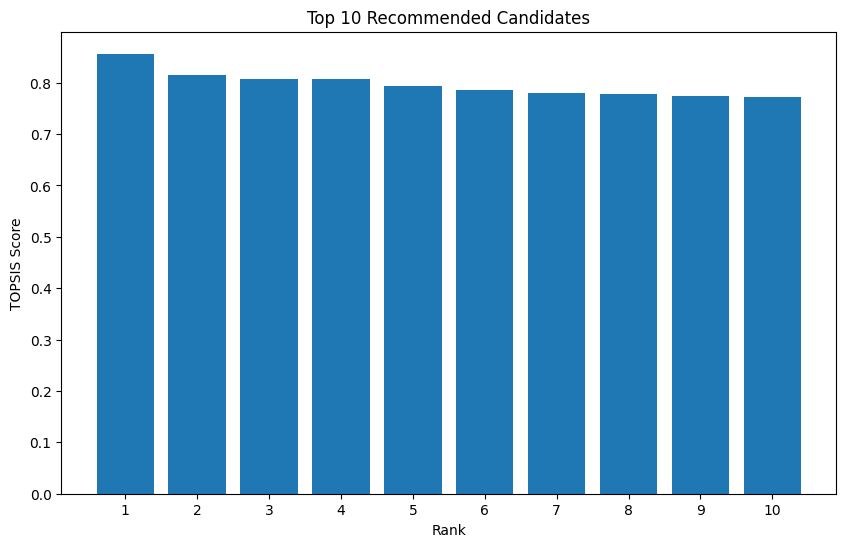

In [41]:
import matplotlib.pyplot as plt

top10 = ranked_df.head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top10["rank"].astype(str),
    top10["topsis_score"]
)

plt.title(
    "Top 10 Recommended Candidates"
)

plt.xlabel("Rank")

plt.ylabel("TOPSIS Score")

plt.show()